In [1]:
# General utilities
import warnings

# Data preparation and analysis
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab and notebook display
from google.colab import files
from IPython.display import display

# Data splitting
from sklearn.model_selection import train_test_split

# Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine-learning models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    roc_auc_score,
    roc_curve
)

# Notebook settings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

# Reproducibility setting
RANDOM_STATE = 42

In [2]:
claims_raw = pd.read_csv('/content/aurorasure_claims.csv')
policyholders_raw = pd.read_excel('/content/aurorasure_policyholders.xlsx',sheet_name="Sheet1",engine="openpyxl")

In [3]:
display(claims_raw.head())
display(policyholders_raw.head())

,claim_id,policy_id,claim_type,claim_amount,days_since_policy_start,num_prior_claims,incident_report_delay_days,is_weekend_claim,claim_channel,fraud_label
0,200001,52306,Motor,1171.62,42,0,4,0,Phone,0
1,200002,50795,Motor,1192.21,3024,2,6,1,Phone,0
2,200003,55049,Travel,3567.16,2241,1,6,0,Phone,0
3,200004,52126,Motor,1311.54,970,0,4,0,Phone,0
4,200005,55662,Motor,1237.59,3538,1,0,0,Broker,0


,policy_id,age,gender,postcode_region,income_band,policy_type,policy_tenure_years,fraud_label
0,52306,79,Male,South,Medium,Premium,3.65,0
1,50795,80,Female,Scotland,High,Standard,0.12,0
2,55049,77,Female,North,Low,Standard,3.87,0
3,52126,51,Female,London,Medium,Premium,4.01,0
4,55662,44,Male,London,Medium,Premium,3.11,0


## **Standardise column names and confirm the schemas**

In [4]:
def standardise_column_names(dataframe):
    dataframe = dataframe.copy()
    dataframe.columns = (
        dataframe.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return dataframe

claims = standardise_column_names(claims_raw)
policyholders = standardise_column_names(policyholders_raw)

expected_claims_columns = {
    "claim_id",
    "policy_id",
    "claim_type",
    "claim_amount",
    "days_since_policy_start",
    "num_prior_claims",
    "incident_report_delay_days",
    "is_weekend_claim",
    "claim_channel",
    "fraud_label"
}

expected_policyholder_columns = {
    "policy_id",
    "age",
    "gender",
    "postcode_region",
    "income_band",
    "policy_type",
    "policy_tenure_years",
    "fraud_label"
}

assert expected_claims_columns.issubset(claims.columns), (
    f"Missing claims columns: {expected_claims_columns - set(claims.columns)}"
)

assert expected_policyholder_columns.issubset(policyholders.columns), (
    f"Missing policyholder columns: "
    f"{expected_policyholder_columns - set(policyholders.columns)}"
)

# **Safely combine the datasets**

In [5]:
assert len(claims) == len(policyholders), (
    "The files have different row counts and require further key investigation."
)

assert claims["policy_id"].equals(policyholders["policy_id"]), (
    "The policy_id sequence differs between the files."
)

assert claims["fraud_label"].equals(policyholders["fraud_label"]), (
    "The two fraud_label columns do not agree."
)

claims["_policy_occurrence"] = claims.groupby("policy_id").cumcount()
policyholders["_policy_occurrence"] = (
    policyholders.groupby("policy_id").cumcount()
)

policyholders_for_merge = policyholders.drop(columns=["fraud_label"])

insurance_data = claims.merge(
    policyholders_for_merge,
    on=["policy_id", "_policy_occurrence"],
    how="inner",
    validate="one_to_one"
)

insurance_data = insurance_data.drop(columns=["_policy_occurrence"])

assert len(insurance_data) == len(claims) == 6000
assert insurance_data["claim_id"].is_unique
assert insurance_data.columns.tolist().count("fraud_label") == 1

print("Combined shape:", insurance_data.shape)
print("Fraud label columns:", [
    column for column in insurance_data.columns
    if "fraud_label" in column
])

display(insurance_data.head())

Combined shape: (6000, 16)
Fraud label columns: ['fraud_label']


,claim_id,policy_id,claim_type,claim_amount,days_since_policy_start,num_prior_claims,incident_report_delay_days,is_weekend_claim,claim_channel,fraud_label,age,gender,postcode_region,income_band,policy_type,policy_tenure_years
0,200001,52306,Motor,1171.62,42,0,4,0,Phone,0,79,Male,South,Medium,Premium,3.65
1,200002,50795,Motor,1192.21,3024,2,6,1,Phone,0,80,Female,Scotland,High,Standard,0.12
2,200003,55049,Travel,3567.16,2241,1,6,0,Phone,0,77,Female,North,Low,Standard,3.87
3,200004,52126,Motor,1311.54,970,0,4,0,Phone,0,51,Female,London,Medium,Premium,4.01
4,200005,55662,Motor,1237.59,3538,1,0,0,Broker,0,44,Male,London,Medium,Premium,3.11


# **Insurance Data Exploration**

In [6]:
print("\nData types:")
display(
    insurance_data.dtypes
    .rename("data_type")
    .to_frame()
)


Data types:


,data_type
claim_id,int64
policy_id,int64
claim_type,object
claim_amount,float64
days_since_policy_start,int64
num_prior_claims,int64
incident_report_delay_days,int64
is_weekend_claim,int64
claim_channel,object
fraud_label,int64


In [7]:
print("\nDataFrame information:")
insurance_data.info()


DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   claim_id                    6000 non-null   int64  
 1   policy_id                   6000 non-null   int64  
 2   claim_type                  6000 non-null   object 
 3   claim_amount                6000 non-null   float64
 4   days_since_policy_start     6000 non-null   int64  
 5   num_prior_claims            6000 non-null   int64  
 6   incident_report_delay_days  6000 non-null   int64  
 7   is_weekend_claim            6000 non-null   int64  
 8   claim_channel               6000 non-null   object 
 9   fraud_label                 6000 non-null   int64  
 10  age                         6000 non-null   int64  
 11  gender                      6000 non-null   object 
 12  postcode_region             6000 non-null   object 
 13  income_ba

## **Missing values, Duplicates, and valid categories**

In [8]:
quality_summary = pd.DataFrame({
    "data_type": insurance_data.dtypes.astype(str),
    "missing_count": insurance_data.isna().sum(),
    "missing_percentage": insurance_data.isna().mean().mul(100).round(2),
    "unique_values": insurance_data.nunique(dropna=False)
})

display(quality_summary)

print("Complete duplicate rows:", insurance_data.duplicated().sum())
print("Duplicated claim IDs:", insurance_data["claim_id"].duplicated().sum())
print("Duplicated policy IDs:", insurance_data["policy_id"].duplicated().sum())
print("Unique claim IDs:", insurance_data["claim_id"].nunique())
print("Unique policy IDs:", insurance_data["policy_id"].nunique())

valid_categories = {
    "claim_type": {"Motor", "Home", "Travel"},
    "claim_channel": {"Online", "Phone", "Broker"},
    "gender": {"Female", "Male", "Other"},
    "postcode_region": {
        "North", "South", "Midlands", "London", "Wales", "Scotland"
    },
    "income_band": {"Low", "Medium", "High"},
    "policy_type": {"Basic", "Standard", "Premium"},
    "is_weekend_claim": {0, 1},
    "fraud_label": {0, 1}
}

for column, accepted_values in valid_categories.items():
    observed_values = set(insurance_data[column].dropna().unique())
    unexpected_values = observed_values - accepted_values
    print(
        f"{column}: observed={sorted(observed_values)}, "
        f"unexpected={sorted(unexpected_values)}"
    )

,data_type,missing_count,missing_percentage,unique_values
claim_id,int64,0,0.0,6000
policy_id,int64,0,0.0,3813
claim_type,object,0,0.0,3
claim_amount,float64,0,0.0,5973
days_since_policy_start,int64,0,0.0,2966
num_prior_claims,int64,0,0.0,7
incident_report_delay_days,int64,0,0.0,15
is_weekend_claim,int64,0,0.0,2
claim_channel,object,0,0.0,3
fraud_label,int64,0,0.0,2


Complete duplicate rows: 0
Duplicated claim IDs: 0
Duplicated policy IDs: 2187
Unique claim IDs: 6000
Unique policy IDs: 3813
claim_type: observed=['Home', 'Motor', 'Travel'], unexpected=[]
claim_channel: observed=['Broker', 'Online', 'Phone'], unexpected=[]
gender: observed=['Female', 'Male', 'Other'], unexpected=[]
postcode_region: observed=['London', 'Midlands', 'North', 'Scotland', 'South', 'Wales'], unexpected=[]
income_band: observed=['High', 'Low', 'Medium'], unexpected=[]
policy_type: observed=['Basic', 'Premium', 'Standard'], unexpected=[]
is_weekend_claim: observed=[np.int64(0), np.int64(1)], unexpected=[]
fraud_label: observed=[np.int64(0), np.int64(1)], unexpected=[]


# **Descriptive statistics and Category distributions**

In [9]:
numeric_columns = insurance_data.select_dtypes(include=np.number).columns
categorical_columns = insurance_data.select_dtypes(exclude=np.number).columns

print("Numerical summary:")
display(insurance_data[numeric_columns].describe().T)

for column in categorical_columns:
    print(f"\nDistribution of {column}:")
    category_table = pd.DataFrame({
        "count": insurance_data[column].value_counts(dropna=False),
        "percentage": insurance_data[column]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    })
    display(category_table)

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
claim_id,6000.0,203000.500000,1732.195139,200001.00,201500.7500,203000.500,204500.250,206000.00
policy_id,6000.0,53003.332667,1732.519071,50001.00,51517.0000,53001.500,54492.250,55999.00
claim_amount,6000.0,2659.401770,1789.760253,64.14,1330.1625,2277.575,3570.395,13127.81
days_since_policy_start,6000.0,1838.630500,1048.935888,1.00,949.0000,1831.000,2752.500,3648.00
num_prior_claims,6000.0,1.098833,1.050991,0.00,0.0000,1.000,2.000,6.00
incident_report_delay_days,6000.0,4.014000,1.986235,0.00,3.0000,4.000,5.000,14.00
is_weekend_claim,6000.0,0.275333,0.446719,0.00,0.0000,0.000,1.000,1.00
fraud_label,6000.0,0.184167,0.387652,0.00,0.0000,0.000,0.000,1.00
age,6000.0,50.560667,19.289030,18.00,34.0000,50.500,67.000,84.00
policy_tenure_years,6000.0,2.996800,2.963763,0.00,0.8700,2.120,4.160,26.96



Distribution of claim_type:


,count,percentage
claim_type,,
Motor,3013,50.22
Home,2120,35.33
Travel,867,14.45



Distribution of claim_channel:


...

,count,percentage
postcode_region,,
London,1019,16.98
South,1017,16.95
Scotland,1004,16.73
Midlands,1004,16.73
Wales,982,16.37
North,974,16.23



Distribution of income_band:


,count,percentage
income_band,,
Medium,2797,46.62
Low,2013,33.55
High,1190,19.83



Distribution of policy_type:


,count,percentage
policy_type,,
Basic,2442,40.70
Standard,2396,39.93
Premium,1162,19.37


# **Detect outliers using the IQR method**

In [10]:
def calculate_iqr_outliers(dataframe, columns):
    results = []

    for column in columns:
        q1 = dataframe[column].quantile(0.25)
        q3 = dataframe[column].quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outlier_mask = (
            (dataframe[column] < lower_limit) |
            (dataframe[column] > upper_limit)
        )

        results.append({
            "variable": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_limit": lower_limit,
            "upper_limit": upper_limit,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_percentage": round(outlier_mask.mean() * 100, 2)
        })

    return pd.DataFrame(results)

outlier_columns = [
    "claim_amount",
    "incident_report_delay_days",
    "days_since_policy_start",
    "num_prior_claims",
    "age",
    "policy_tenure_years"
]

outlier_summary = calculate_iqr_outliers(
    insurance_data,
    outlier_columns
)

display(outlier_summary)

,variable,q1,q3,iqr,lower_limit,upper_limit,outlier_count,outlier_percentage
0,claim_amount,1330.1625,3570.395,2240.2325,-2030.18625,6930.74375,166,2.77
1,incident_report_delay_days,3.0000,5.000,2.0000,0.00000,8.00000,129,2.15
2,days_since_policy_start,949.0000,2752.500,1803.5000,-1756.25000,5457.75000,0,0.00
3,num_prior_claims,0.0000,2.000,2.0000,-3.00000,5.00000,5,0.08
4,age,34.0000,67.000,33.0000,-15.50000,116.50000,0,0.00
5,policy_tenure_years,0.8700,4.160,3.2900,-4.06500,9.09500,274,4.57


## **Outlier plot 1: claim amount**

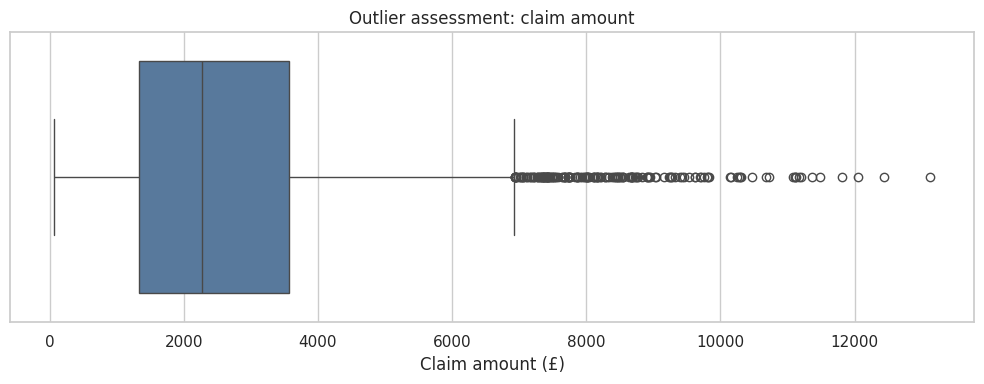

In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=insurance_data,
    x="claim_amount",
    color="#4C78A8"
)
plt.title("Outlier assessment: claim amount")
plt.xlabel("Claim amount (£)")
plt.tight_layout()
plt.show()

## **Outlier plot 2: policy tenure**

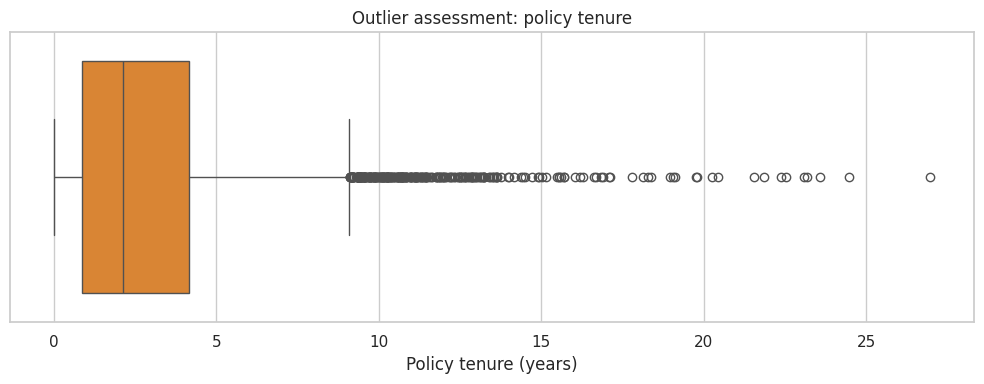

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=insurance_data,
    x="policy_tenure_years",
    color="#F58518"
)
plt.title("Outlier assessment: policy tenure")
plt.xlabel("Policy tenure (years)")
plt.tight_layout()
plt.show()

# **Clean and validate the combined data**

In [13]:
insurance_clean = insurance_data.copy()

text_columns = insurance_clean.select_dtypes(include="object").columns

for column in text_columns:
    insurance_clean[column] = (
        insurance_clean[column]
        .astype("string")
        .str.strip()
        .str.title()
    )

insurance_clean = insurance_clean.drop_duplicates().copy()

numeric_nonnegative_columns = [
    "claim_amount",
    "days_since_policy_start",
    "num_prior_claims",
    "incident_report_delay_days",
    "policy_tenure_years"
]

for column in numeric_nonnegative_columns:
    invalid_mask = insurance_clean[column] < 0
    insurance_clean.loc[invalid_mask, column] = np.nan

insurance_clean.loc[
    ~insurance_clean["age"].between(18, 100),
    "age"
] = np.nan

insurance_clean.loc[
    ~insurance_clean["is_weekend_claim"].isin([0, 1]),
    "is_weekend_claim"
] = np.nan

insurance_clean.loc[
    ~insurance_clean["fraud_label"].isin([0, 1]),
    "fraud_label"
] = np.nan

assert insurance_clean["claim_id"].is_unique
assert insurance_clean["claim_id"].gt(0).all()
assert insurance_clean["policy_id"].gt(0).all()
assert insurance_clean["fraud_label"].notna().all()

print("Cleaned shape:", insurance_clean.shape)
print("Remaining missing values:", insurance_clean.isna().sum().sum())
display(insurance_clean.head())

Cleaned shape: (6000, 16)
Remaining missing values: 0


,claim_id,policy_id,claim_type,claim_amount,days_since_policy_start,num_prior_claims,incident_report_delay_days,is_weekend_claim,claim_channel,fraud_label,age,gender,postcode_region,income_band,policy_type,policy_tenure_years
0,200001,52306,Motor,1171.62,42.0,0.0,4.0,0.0,Phone,0.0,79.0,Male,South,Medium,Premium,3.65
1,200002,50795,Motor,1192.21,3024.0,2.0,6.0,1.0,Phone,0.0,80.0,Female,Scotland,High,Standard,0.12
2,200003,55049,Travel,3567.16,2241.0,1.0,6.0,0.0,Phone,0.0,77.0,Female,North,Low,Standard,3.87
3,200004,52126,Motor,1311.54,970.0,0.0,4.0,0.0,Phone,0.0,51.0,Female,London,Medium,Premium,4.01
4,200005,55662,Motor,1237.59,3538.0,1.0,0.0,0.0,Broker,0.0,44.0,Male,London,Medium,Premium,3.11


# **Descriptive Statistics**

In [14]:
def add_count_labels(axis, decimal_places=0):
    for container in axis.containers:
        labels = []

        for bar in container:
            height = bar.get_height()

            if np.isnan(height):
                labels.append("")
            elif decimal_places == 0:
                labels.append(f"{height:,.0f}")
            else:
                labels.append(f"{height:,.{decimal_places}f}")

        axis.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

def add_percentage_labels(axis, decimal_places=1):
    for container in axis.containers:
        labels = []

        for bar in container:
            height = bar.get_height()

            if np.isnan(height):
                labels.append("")
            else:
                labels.append(
                    f"{height:.{decimal_places}f}%"
                )

        axis.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

def format_chart(axis, title, xlabel, ylabel):
    axis.set_title(title, fontsize=14, fontweight="bold", pad=14)
    axis.set_xlabel(xlabel, fontsize=11)
    axis.set_ylabel(ylabel, fontsize=11)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

## **Number of records**

In [15]:
number_of_records = len(insurance_clean)

record_summary = pd.DataFrame({
    "measure": ["Number of insurance claims"],
    "value": [number_of_records]
})

display(record_summary)

print(f"Number of records: {number_of_records:,}")

,measure,value
0,Number of insurance claims,6000


Number of records: 6,000


## **Percentage of fraudulent claims**

In [16]:
fraud_count = int(insurance_clean["fraud_label"].sum())
legitimate_count = int(
    (insurance_clean["fraud_label"] == 0).sum()
)
fraud_percentage = (
    insurance_clean["fraud_label"].mean() * 100
)

fraud_summary = pd.DataFrame({
    "claim_status": ["Legitimate", "Fraudulent", "Total"],
    "number_of_claims": [
        legitimate_count,
        fraud_count,
        number_of_records
    ],
    "percentage": [
        legitimate_count / number_of_records * 100,
        fraud_percentage,
        100
    ]
})

display(fraud_summary.round(2))

print(f"Fraudulent claims: {fraud_count:,}")
print(f"Fraud percentage: {fraud_percentage:.2f}%")

,claim_status,number_of_claims,percentage
0,Legitimate,4895,81.58
1,Fraudulent,1105,18.42
2,Total,6000,100.00


Fraudulent claims: 1,105
Fraud percentage: 18.42%


## **Plot legitimate and fraudulent claim proportions**

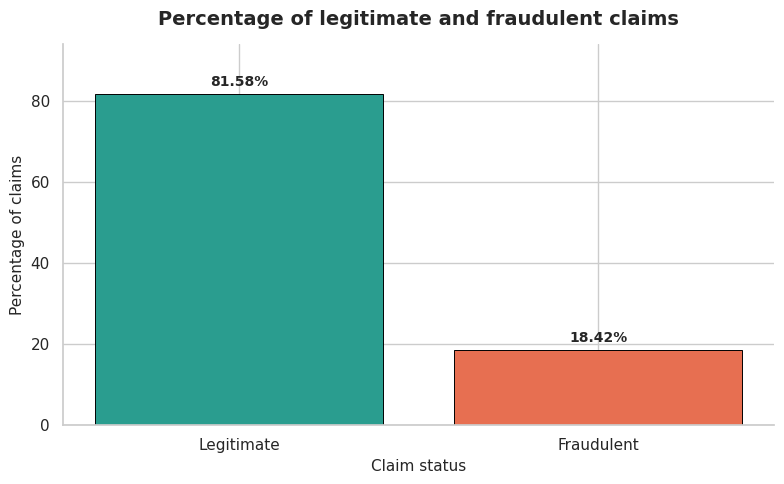

In [17]:
fraud_status_plot = (
    insurance_clean["fraud_label"]
    .map({0: "Legitimate", 1: "Fraudulent"})
    .value_counts()
    .rename_axis("claim_status")
    .reset_index(name="number_of_claims")
)

fraud_status_plot["percentage"] = (
    fraud_status_plot["number_of_claims"]
    / fraud_status_plot["number_of_claims"].sum()
    * 100
)

fig, axis = plt.subplots(figsize=(8, 5))

bars = axis.bar(
    fraud_status_plot["claim_status"],
    fraud_status_plot["percentage"],
    color=["#2A9D8F", "#E76F51"],
    edgecolor="black",
    linewidth=0.7
)

axis.bar_label(
    bars,
    labels=[
        f"{percentage:.2f}%"
        for percentage in fraud_status_plot["percentage"]
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

format_chart(
    axis,
    "Percentage of legitimate and fraudulent claims",
    "Claim status",
    "Percentage of claims"
)

axis.set_ylim(
    0,
    fraud_status_plot["percentage"].max() * 1.15
)

plt.tight_layout()
plt.show()

## **Fraud rate by claim type**

In [18]:
fraud_by_claim_type = (
    insurance_clean
    .groupby("claim_type", observed=False)["fraud_label"]
    .agg(
        total_claims="size",
        fraudulent_claims="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

fraud_by_claim_type["fraud_rate_percentage"] = (
    fraud_by_claim_type["fraud_rate"] * 100
)

fraud_by_claim_type = fraud_by_claim_type.sort_values(
    "fraud_rate_percentage",
    ascending=False
)

display(fraud_by_claim_type.round(2))

,claim_type,total_claims,fraudulent_claims,fraud_rate,fraud_rate_percentage
2,Travel,867,197.0,0.23,22.72
1,Motor,3013,551.0,0.18,18.29
0,Home,2120,357.0,0.17,16.84


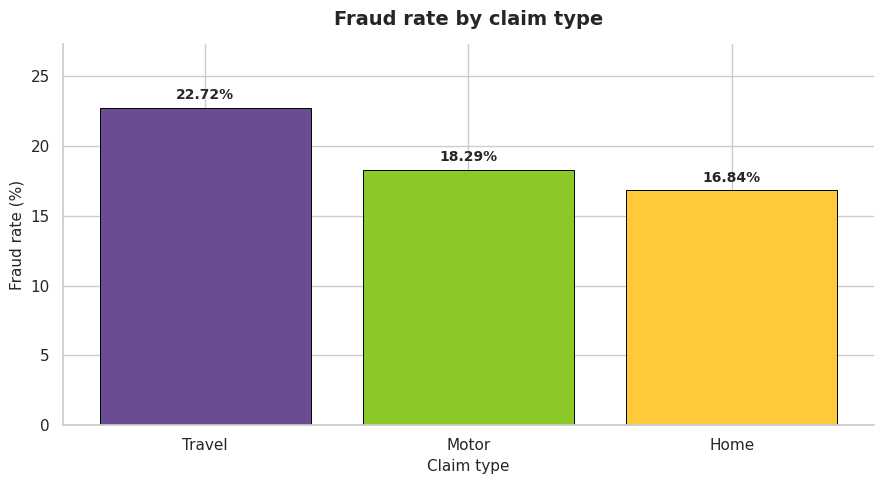

In [19]:
fig, axis = plt.subplots(figsize=(9, 5))

bars = axis.bar(
    fraud_by_claim_type["claim_type"],
    fraud_by_claim_type["fraud_rate_percentage"],
    color=["#6A4C93", "#8AC926", "#FFCA3A"],
    edgecolor="black",
    linewidth=0.7
)

axis.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in fraud_by_claim_type[
            "fraud_rate_percentage"
        ]
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

format_chart(
    axis,
    "Fraud rate by claim type",
    "Claim type",
    "Fraud rate (%)"
)

axis.set_ylim(
    0,
    fraud_by_claim_type["fraud_rate_percentage"].max() * 1.20
)

plt.tight_layout()
plt.show()

# **Mean, median, standard deviation and IQR**

In [20]:
descriptive_variables = [
    "claim_amount",
    "incident_report_delay_days",
    "days_since_policy_start"
]

descriptive_statistics = pd.DataFrame({
    "mean": insurance_clean[descriptive_variables].mean(),
    "median": insurance_clean[descriptive_variables].median(),
    "standard_deviation": (
        insurance_clean[descriptive_variables].std()
    ),
    "first_quartile": (
        insurance_clean[descriptive_variables].quantile(0.25)
    ),
    "third_quartile": (
        insurance_clean[descriptive_variables].quantile(0.75)
    )
})

descriptive_statistics["interquartile_range"] = (
    descriptive_statistics["third_quartile"]
    - descriptive_statistics["first_quartile"]
)

descriptive_statistics = (
    descriptive_statistics
    .reset_index()
    .rename(columns={"index": "variable"})
)

display(descriptive_statistics.round(2))

,variable,mean,median,standard_deviation,first_quartile,third_quartile,interquartile_range
0,claim_amount,2659.40,2277.57,1789.76,1330.16,3570.4,2240.23
1,incident_report_delay_days,4.01,4.00,1.99,3.00,5.0,2.00
2,days_since_policy_start,1838.63,1831.00,1048.94,949.00,2752.5,1803.50


# **Distribution plots**

### **Plot the distribution of claim amount**

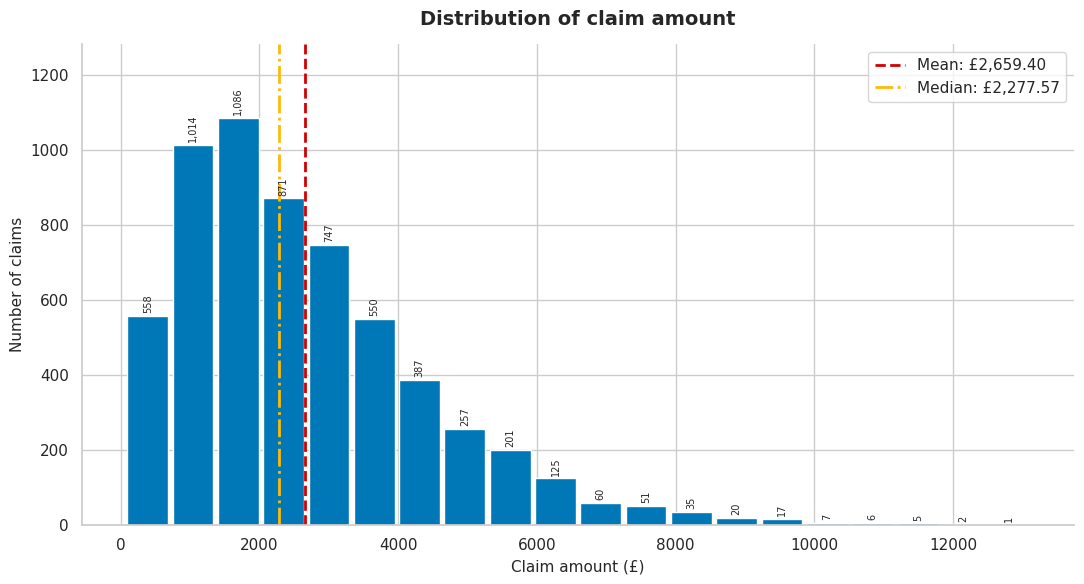

In [21]:
claim_amount_counts, claim_amount_bins = np.histogram(
    insurance_clean["claim_amount"].dropna(),
    bins=20
)

claim_amount_centres = (
    claim_amount_bins[:-1] + claim_amount_bins[1:]
) / 2

claim_amount_widths = np.diff(claim_amount_bins)

fig, axis = plt.subplots(figsize=(11, 6))

bars = axis.bar(
    claim_amount_centres,
    claim_amount_counts,
    width=claim_amount_widths * 0.90,
    color="#0077B6",
    edgecolor="white"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}" if count > 0 else ""
        for count in claim_amount_counts
    ],
    padding=2,
    fontsize=7,
    rotation=90
)

mean_claim_amount = insurance_clean["claim_amount"].mean()
median_claim_amount = insurance_clean["claim_amount"].median()

axis.axvline(
    mean_claim_amount,
    color="#D00000",
    linestyle="--",
    linewidth=2,
    label=f"Mean: £{mean_claim_amount:,.2f}"
)

axis.axvline(
    median_claim_amount,
    color="#FFBA08",
    linestyle="-.",
    linewidth=2,
    label=f"Median: £{median_claim_amount:,.2f}"
)

format_chart(
    axis,
    "Distribution of claim amount",
    "Claim amount (£)",
    "Number of claims"
)

axis.legend()
axis.margins(y=0.18)

plt.tight_layout()
plt.show()

### **Plot the distribution of reporting delay**

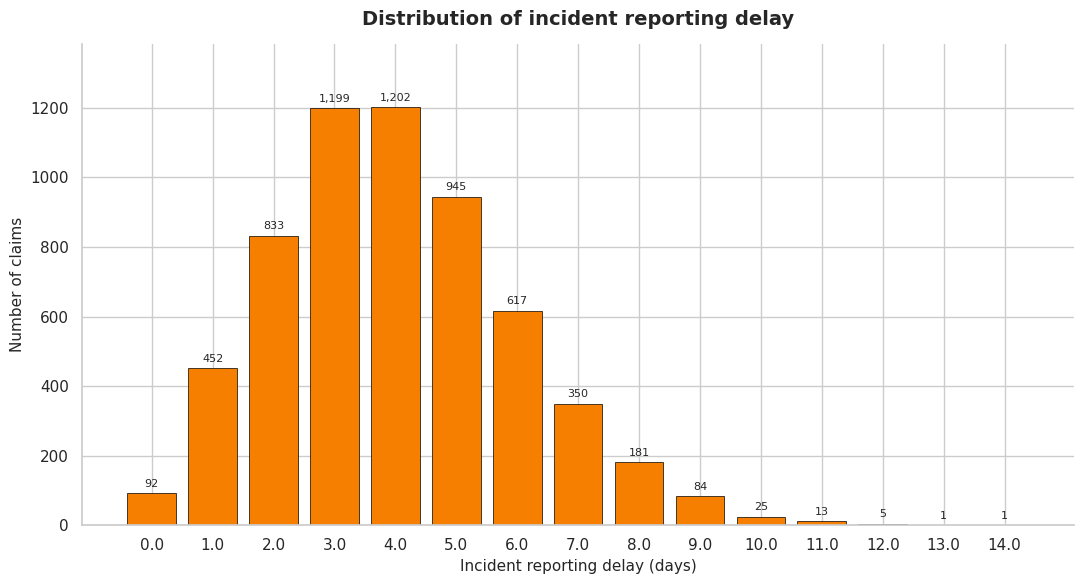

In [22]:
reporting_delay_counts = (
    insurance_clean["incident_report_delay_days"]
    .value_counts()
    .sort_index()
)

fig, axis = plt.subplots(figsize=(11, 6))

bars = axis.bar(
    reporting_delay_counts.index.astype(str),
    reporting_delay_counts.values,
    color="#F77F00",
    edgecolor="black",
    linewidth=0.5
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}"
        for count in reporting_delay_counts.values
    ],
    padding=3,
    fontsize=8
)

format_chart(
    axis,
    "Distribution of incident reporting delay",
    "Incident reporting delay (days)",
    "Number of claims"
)

axis.margins(y=0.15)

plt.tight_layout()
plt.show()

## **Plot the distribution of days since policy start**

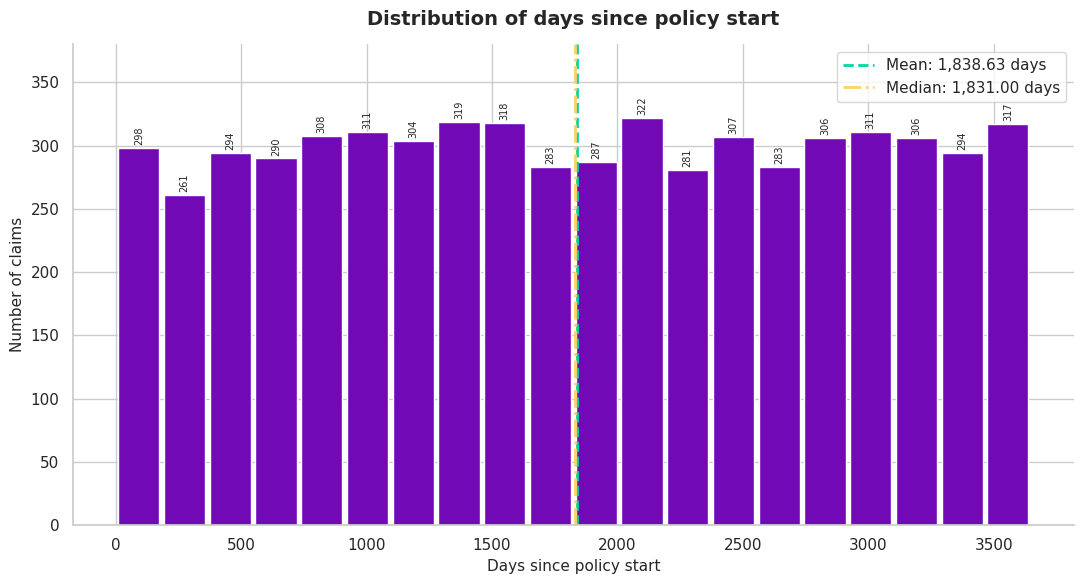

In [23]:
policy_days_counts, policy_days_bins = np.histogram(
    insurance_clean["days_since_policy_start"].dropna(),
    bins=20
)

policy_days_centres = (
    policy_days_bins[:-1] + policy_days_bins[1:]
) / 2

policy_days_widths = np.diff(policy_days_bins)

fig, axis = plt.subplots(figsize=(11, 6))

bars = axis.bar(
    policy_days_centres,
    policy_days_counts,
    width=policy_days_widths * 0.90,
    color="#7209B7",
    edgecolor="white"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}" if count > 0 else ""
        for count in policy_days_counts
    ],
    padding=2,
    fontsize=7,
    rotation=90
)

mean_policy_days = (
    insurance_clean["days_since_policy_start"].mean()
)
median_policy_days = (
    insurance_clean["days_since_policy_start"].median()
)

axis.axvline(
    mean_policy_days,
    color="#06D6A0",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_policy_days:,.2f} days"
)

axis.axvline(
    median_policy_days,
    color="#FFD166",
    linestyle="-.",
    linewidth=2,
    label=f"Median: {median_policy_days:,.2f} days"
)

format_chart(
    axis,
    "Distribution of days since policy start",
    "Days since policy start",
    "Number of claims"
)

axis.legend()
axis.margins(y=0.18)

plt.tight_layout()
plt.show()

# **Mean and median claim amount by fraud label**

### **Claim amount by fraud label**

In [24]:
claim_amount_by_fraud = (
    insurance_clean
    .assign(
        claim_status=insurance_clean["fraud_label"].map({
            0: "Legitimate",
            1: "Fraudulent"
        })
    )
    .groupby("claim_status", observed=False)["claim_amount"]
    .agg(
        number_of_claims="size",
        mean_claim_amount="mean",
        median_claim_amount="median"
    )
    .reset_index()
)

display(claim_amount_by_fraud.round(2))

,claim_status,number_of_claims,mean_claim_amount,median_claim_amount
0,Fraudulent,1105,2732.88,2422.39
1,Legitimate,4895,2642.81,2250.46


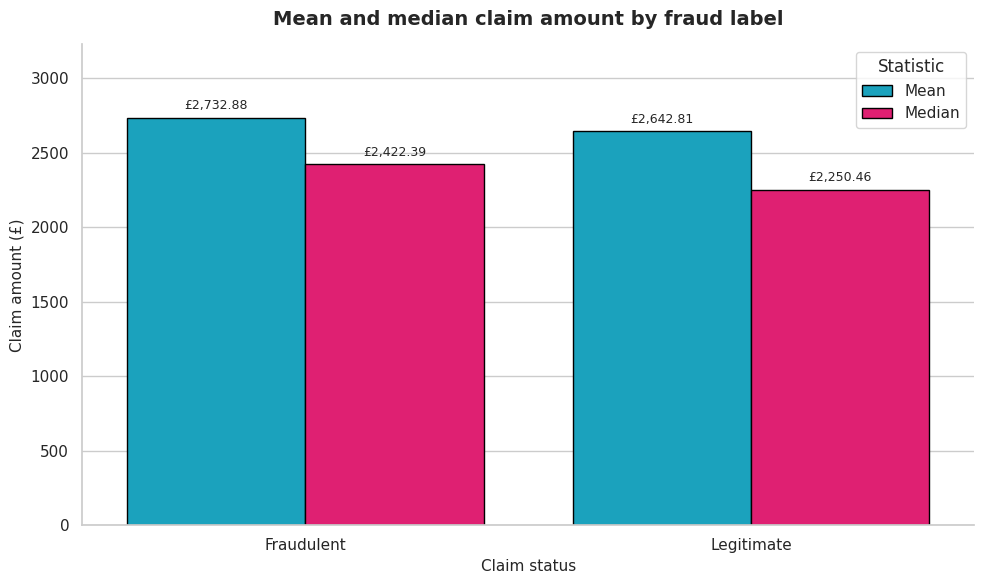

In [25]:
claim_amount_long = claim_amount_by_fraud.melt(
    id_vars="claim_status",
    value_vars=[
        "mean_claim_amount",
        "median_claim_amount"
    ],
    var_name="measure",
    value_name="claim_amount"
)

claim_amount_long["measure"] = (
    claim_amount_long["measure"]
    .map({
        "mean_claim_amount": "Mean",
        "median_claim_amount": "Median"
    })
)

fig, axis = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=claim_amount_long,
    x="claim_status",
    y="claim_amount",
    hue="measure",
    palette={
        "Mean": "#00B4D8",
        "Median": "#FF006E"
    },
    edgecolor="black",
    ax=axis
)

for container in axis.containers:
    axis.bar_label(
        container,
        labels=[
            f"£{bar.get_height():,.2f}"
            for bar in container
        ],
        padding=4,
        fontsize=9
    )

format_chart(
    axis,
    "Mean and median claim amount by fraud label",
    "Claim status",
    "Claim amount (£)"
)

axis.legend(title="Statistic")
axis.margins(y=0.18)

plt.tight_layout()
plt.show()

## **Distribution of claim type, channel and policy type**

In [26]:
def category_distribution(dataframe, column):
    output = (
        dataframe[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="number_of_claims")
    )

    output["percentage"] = (
        output["number_of_claims"]
        / output["number_of_claims"].sum()
        * 100
    )

    return output

claim_type_distribution = category_distribution(
    insurance_clean,
    "claim_type"
)

claim_channel_distribution = category_distribution(
    insurance_clean,
    "claim_channel"
)

policy_type_distribution = category_distribution(
    insurance_clean,
    "policy_type"
)

print("Claim type distribution:")
display(claim_type_distribution.round(2))

print("Claim channel distribution:")
display(claim_channel_distribution.round(2))

print("Policy type distribution:")
display(policy_type_distribution.round(2))

Claim type distribution:


,claim_type,number_of_claims,percentage
0,Motor,3013,50.22
1,Home,2120,35.33
2,Travel,867,14.45


Claim channel distribution:


,claim_channel,number_of_claims,percentage
0,Online,3299,54.98
1,Phone,1805,30.08
2,Broker,896,14.93


Policy type distribution:


,policy_type,number_of_claims,percentage
0,Basic,2442,40.7
1,Standard,2396,39.93
2,Premium,1162,19.37


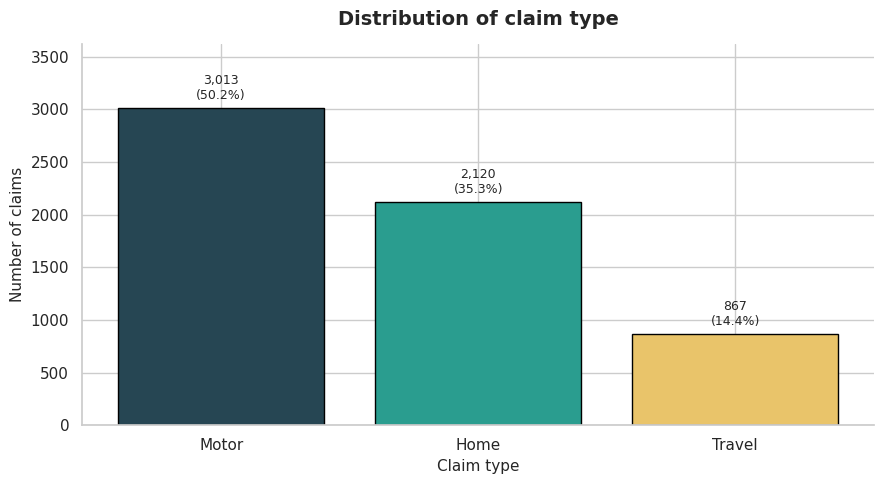

In [27]:
fig, axis = plt.subplots(figsize=(9, 5))

bars = axis.bar(
    claim_type_distribution["claim_type"],
    claim_type_distribution["number_of_claims"],
    color=["#264653", "#2A9D8F", "#E9C46A"],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}\n({percentage:.1f}%)"
        for count, percentage in zip(
            claim_type_distribution["number_of_claims"],
            claim_type_distribution["percentage"]
        )
    ],
    padding=4,
    fontsize=9
)

format_chart(
    axis,
    "Distribution of claim type",
    "Claim type",
    "Number of claims"
)

axis.margins(y=0.20)

plt.tight_layout()
plt.show()

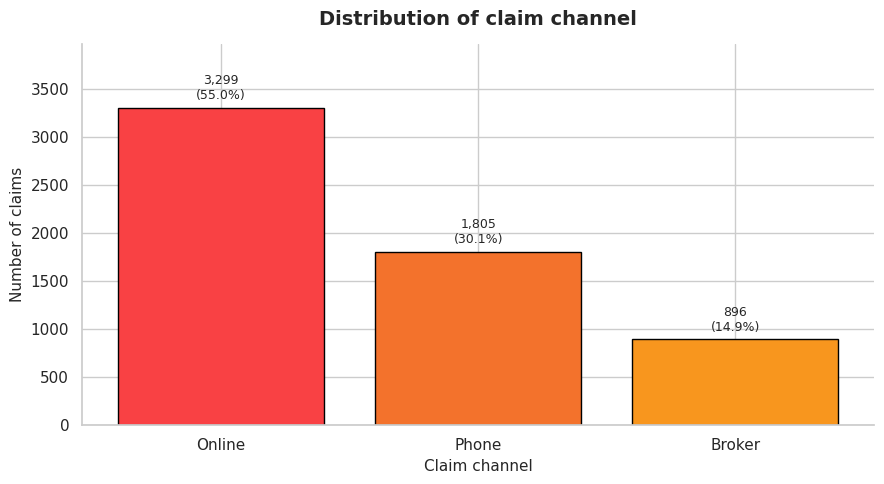

In [28]:
fig, axis = plt.subplots(figsize=(9, 5))

bars = axis.bar(
    claim_channel_distribution["claim_channel"],
    claim_channel_distribution["number_of_claims"],
    color=["#F94144", "#F3722C", "#F8961E"],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}\n({percentage:.1f}%)"
        for count, percentage in zip(
            claim_channel_distribution["number_of_claims"],
            claim_channel_distribution["percentage"]
        )
    ],
    padding=4,
    fontsize=9
)

format_chart(
    axis,
    "Distribution of claim channel",
    "Claim channel",
    "Number of claims"
)

axis.margins(y=0.20)

plt.tight_layout()
plt.show()

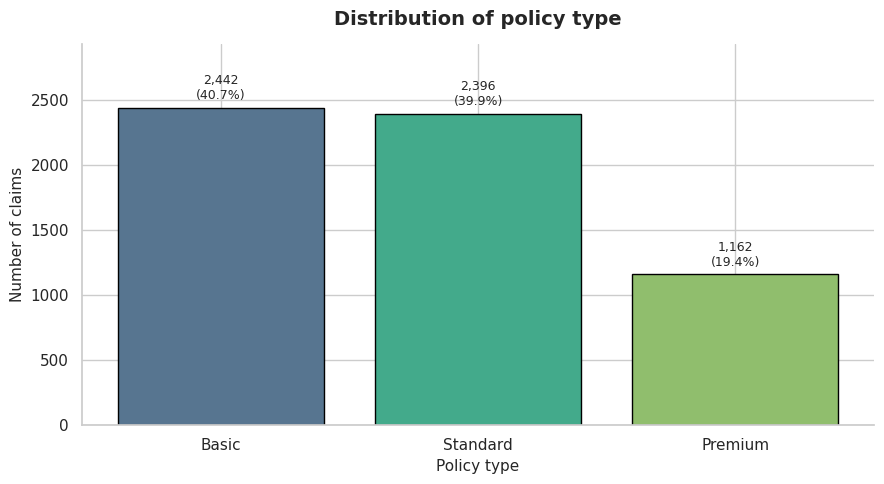

In [29]:
fig, axis = plt.subplots(figsize=(9, 5))

bars = axis.bar(
    policy_type_distribution["policy_type"],
    policy_type_distribution["number_of_claims"],
    color=["#577590", "#43AA8B", "#90BE6D"],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}\n({percentage:.1f}%)"
        for count, percentage in zip(
            policy_type_distribution["number_of_claims"],
            policy_type_distribution["percentage"]
        )
    ],
    padding=4,
    fontsize=9
)

format_chart(
    axis,
    "Distribution of policy type",
    "Policy type",
    "Number of claims"
)

axis.margins(y=0.20)

plt.tight_layout()
plt.show()

# **Fraud rate by region, income band and policy type**

In [30]:
def calculate_fraud_rate(dataframe, group_column):
    result = (
        dataframe
        .groupby(group_column, observed=False)["fraud_label"]
        .agg(
            total_claims="size",
            fraudulent_claims="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    result["fraud_rate_percentage"] = (
        result["fraud_rate"] * 100
    )

    return result.sort_values(
        "fraud_rate_percentage",
        ascending=False
    )

fraud_by_region = calculate_fraud_rate(
    insurance_clean,
    "postcode_region"
)

fraud_by_income = calculate_fraud_rate(
    insurance_clean,
    "income_band"
)

fraud_by_policy_type = calculate_fraud_rate(
    insurance_clean,
    "policy_type"
)

print("Fraud rate by region:")
display(fraud_by_region.round(2))

print("Fraud rate by income band:")
display(fraud_by_income.round(2))

print("Fraud rate by policy type:")
display(fraud_by_policy_type.round(2))

Fraud rate by region:


,postcode_region,total_claims,fraudulent_claims,fraud_rate,fraud_rate_percentage
3,Scotland,1004,190.0,0.19,18.92
1,Midlands,1004,187.0,0.19,18.63
5,Wales,982,182.0,0.19,18.53
2,North,974,179.0,0.18,18.38
0,London,1019,186.0,0.18,18.25
4,South,1017,181.0,0.18,17.80


Fraud rate by income band:


,income_band,total_claims,fraudulent_claims,fraud_rate,fraud_rate_percentage
0,High,1190,230.0,0.19,19.33
1,Low,2013,387.0,0.19,19.23
2,Medium,2797,488.0,0.17,17.45


Fraud rate by policy type:


,policy_type,total_claims,fraudulent_claims,fraud_rate,fraud_rate_percentage
1,Premium,1162,227.0,0.20,19.54
2,Standard,2396,463.0,0.19,19.32
0,Basic,2442,415.0,0.17,16.99


## **Plot fraud rate by region**

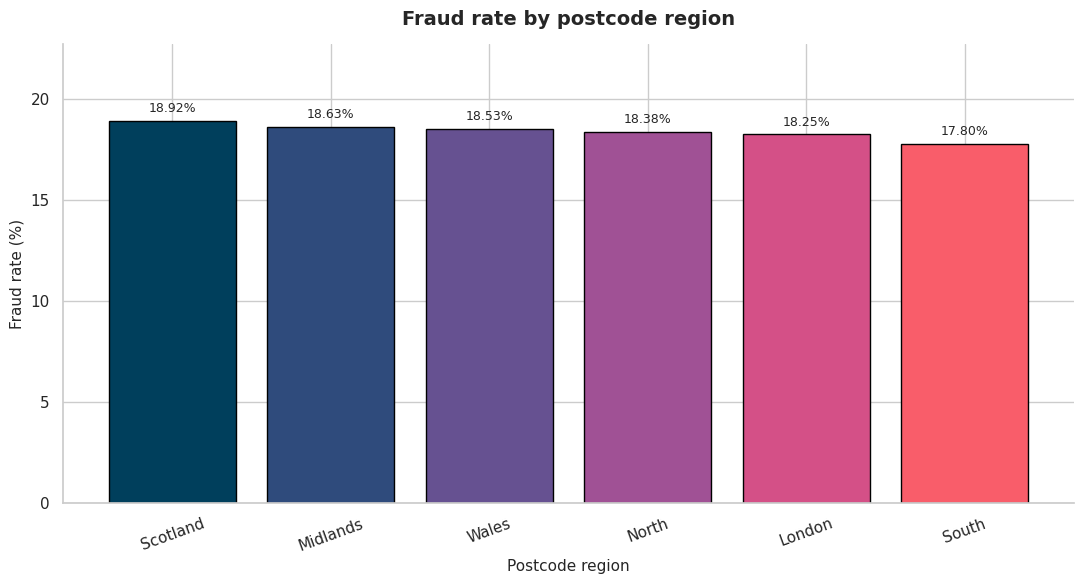

In [31]:
fig, axis = plt.subplots(figsize=(11, 6))

bars = axis.bar(
    fraud_by_region["postcode_region"],
    fraud_by_region["fraud_rate_percentage"],
    color=[
        "#003F5C",
        "#2F4B7C",
        "#665191",
        "#A05195",
        "#D45087",
        "#F95D6A"
    ],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in fraud_by_region["fraud_rate_percentage"]
    ],
    padding=4,
    fontsize=9
)

format_chart(
    axis,
    "Fraud rate by postcode region",
    "Postcode region",
    "Fraud rate (%)"
)

axis.margins(y=0.20)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## **Plot fraud rate by income band**

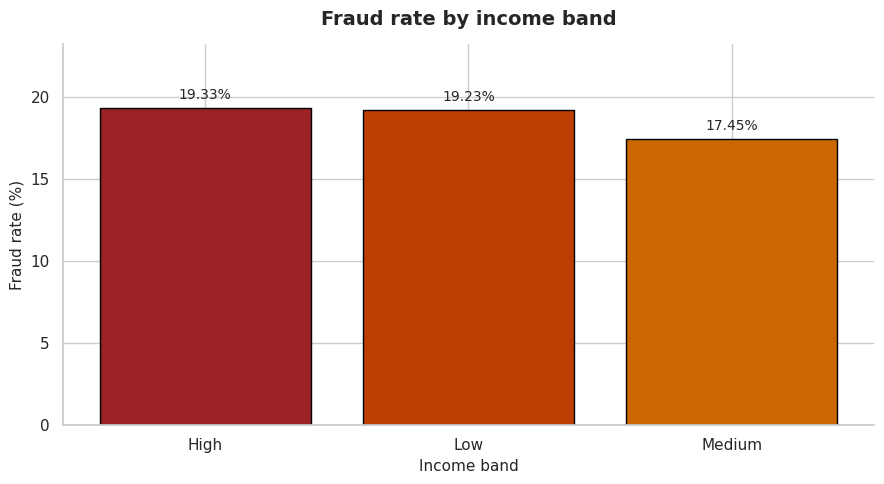

In [32]:
fig, axis = plt.subplots(figsize=(9, 5))

bars = axis.bar(
    fraud_by_income["income_band"],
    fraud_by_income["fraud_rate_percentage"],
    color=["#9B2226", "#BB3E03", "#CA6702"],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in fraud_by_income["fraud_rate_percentage"]
    ],
    padding=4,
    fontsize=10
)

format_chart(
    axis,
    "Fraud rate by income band",
    "Income band",
    "Fraud rate (%)"
)

axis.margins(y=0.20)

plt.tight_layout()
plt.show()

## **Plot fraud rate by policy type**

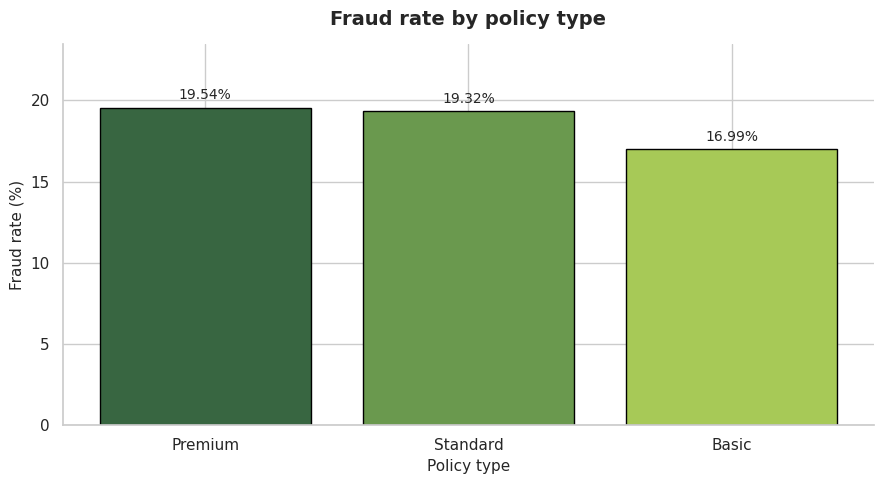

In [33]:
fig, axis = plt.subplots(figsize=(9, 5))

bars = axis.bar(
    fraud_by_policy_type["policy_type"],
    fraud_by_policy_type["fraud_rate_percentage"],
    color=["#386641", "#6A994E", "#A7C957"],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in fraud_by_policy_type[
            "fraud_rate_percentage"
        ]
    ],
    padding=4,
    fontsize=10
)

format_chart(
    axis,
    "Fraud rate by policy type",
    "Policy type",
    "Fraud rate (%)"
)

axis.margins(y=0.20)

plt.tight_layout()
plt.show()

## **Age distribution**

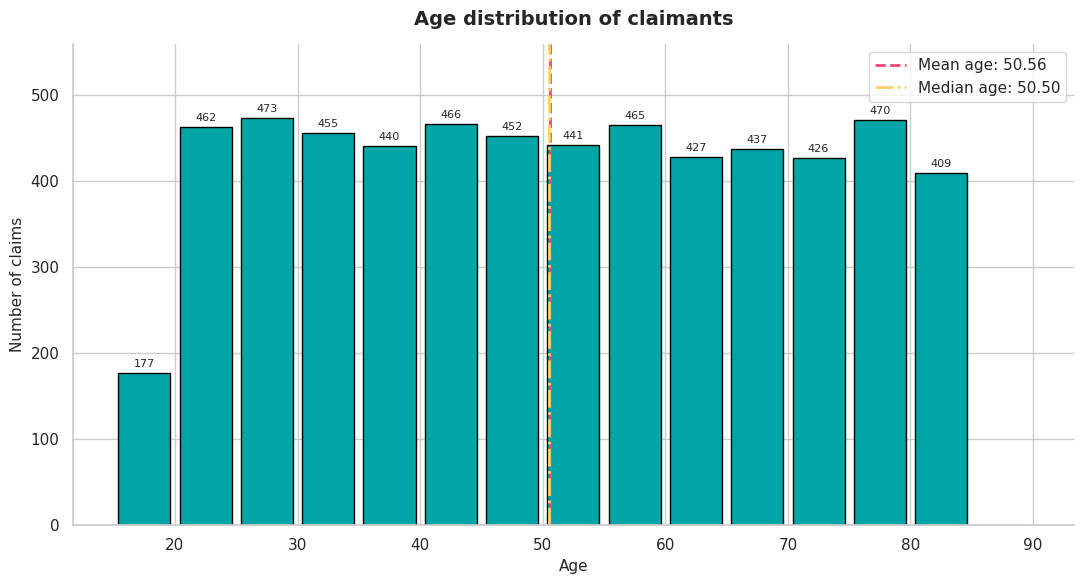

In [34]:
age_counts, age_bins = np.histogram(
    insurance_clean["age"].dropna(),
    bins=range(15, 91, 5)
)

age_centres = (
    np.array(age_bins[:-1]) + np.array(age_bins[1:])
) / 2

age_widths = np.diff(age_bins)

fig, axis = plt.subplots(figsize=(11, 6))

bars = axis.bar(
    age_centres,
    age_counts,
    width=age_widths * 0.85,
    color="#00A6A6",
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}" if count > 0 else ""
        for count in age_counts
    ],
    padding=3,
    fontsize=8
)

mean_age = insurance_clean["age"].mean()
median_age = insurance_clean["age"].median()

axis.axvline(
    mean_age,
    color="#EF476F",
    linestyle="--",
    linewidth=2,
    label=f"Mean age: {mean_age:.2f}"
)

axis.axvline(
    median_age,
    color="#FFD166",
    linestyle="-.",
    linewidth=2,
    label=f"Median age: {median_age:.2f}"
)

format_chart(
    axis,
    "Age distribution of claimants",
    "Age",
    "Number of claims"
)

axis.legend()
axis.margins(y=0.18)

plt.tight_layout()
plt.show()

## **Gender proportion and fraud rate by gender**

In [35]:
gender_proportion = (
    insurance_clean["gender"]
    .value_counts(dropna=False)
    .rename_axis("gender")
    .reset_index(name="number_of_claims")
)

gender_proportion["percentage"] = (
    gender_proportion["number_of_claims"]
    / gender_proportion["number_of_claims"].sum()
    * 100
)

display(gender_proportion.round(2))

,gender,number_of_claims,percentage
0,Female,3005,50.08
1,Male,2866,47.77
2,Other,129,2.15


## **Fraud rate by gender**

In [36]:
fraud_by_gender = calculate_fraud_rate(
    insurance_clean,
    "gender"
)

display(fraud_by_gender.round(2))

,gender,total_claims,fraudulent_claims,fraud_rate,fraud_rate_percentage
1,Male,2866,530.0,0.18,18.49
0,Female,3005,554.0,0.18,18.44
2,Other,129,21.0,0.16,16.28


## **Relationships among numeric variables**

In [37]:
relationship_variables = [
    "claim_amount",
    "num_prior_claims",
    "policy_tenure_years",
    "days_since_policy_start"
]

relationship_correlation = (
    insurance_clean[relationship_variables]
    .corr(method="pearson")
)

display(relationship_correlation.round(3))

,claim_amount,num_prior_claims,policy_tenure_years,days_since_policy_start
claim_amount,1.000,0.002,-0.021,-0.016
num_prior_claims,0.002,1.000,0.007,0.013
policy_tenure_years,-0.021,0.007,1.000,-0.018
days_since_policy_start,-0.016,0.013,-0.018,1.000


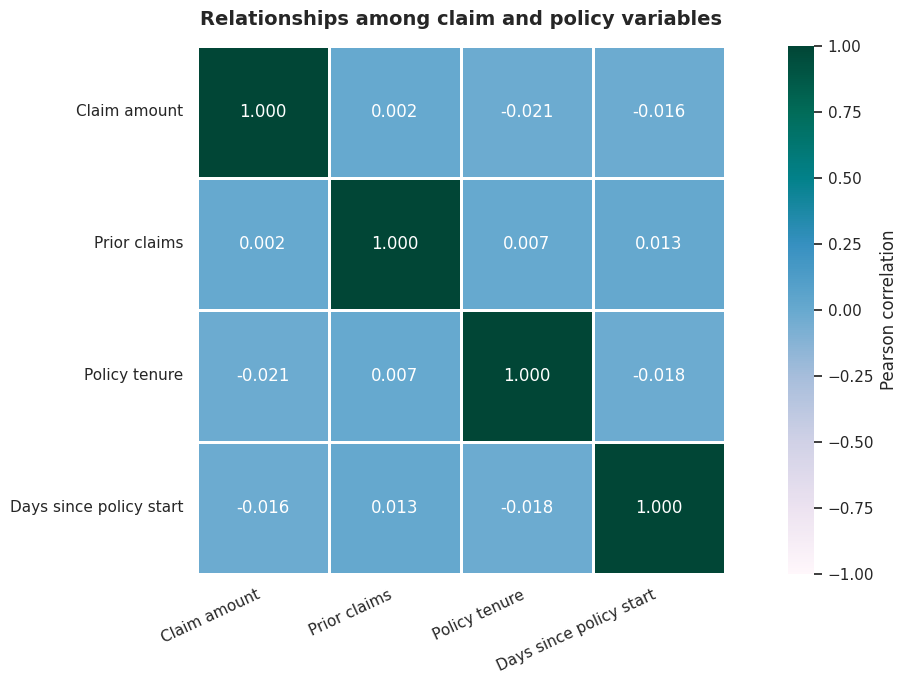

In [38]:
friendly_relationship_labels = {
    "claim_amount": "Claim amount",
    "num_prior_claims": "Prior claims",
    "policy_tenure_years": "Policy tenure",
    "days_since_policy_start": "Days since policy start"
}

labelled_correlation = relationship_correlation.rename(
    index=friendly_relationship_labels,
    columns=friendly_relationship_labels
)

fig, axis = plt.subplots(figsize=(13, 7))

sns.heatmap(
    labelled_correlation,
    annot=True,
    fmt=".3f",
    cmap="PuBuGn",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"},
    ax=axis
)

axis.set_title(
    "Relationships among claim and policy variables",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **Data Preparation**

## **Inspect the target-variable balance**

In [39]:
target_distribution = (
    insurance_clean["fraud_label"]
    .value_counts()
    .sort_index()
    .rename_axis("fraud_label")
    .reset_index(name="number_of_claims")
)

target_distribution["claim_status"] = (
    target_distribution["fraud_label"]
    .map({
        0: "Legitimate",
        1: "Fraudulent"
    })
)

target_distribution["percentage"] = (
    target_distribution["number_of_claims"]
    / target_distribution["number_of_claims"].sum()
    * 100
)

display(
    target_distribution[
        [
            "fraud_label",
            "claim_status",
            "number_of_claims",
            "percentage"
        ]
    ].round(2)
)

print(
    "Fraud prevalence:",
    f"{insurance_clean['fraud_label'].mean():.2%}"
)

,fraud_label,claim_status,number_of_claims,percentage
0,0.0,Legitimate,4895,81.58
1,1.0,Fraudulent,1105,18.42


Fraud prevalence: 18.42%


In [40]:
target_column = "fraud_label"

identifier_columns = [
    "claim_id",
    "policy_id"
]

sensitive_columns = [
    "age",
    "gender"
]

excluded_columns = (
    identifier_columns
    + sensitive_columns
    + [target_column]
)

X = insurance_clean.drop(columns=excluded_columns).copy()
y = insurance_clean[target_column].astype(int).copy()

fairness_data = insurance_clean[
    [
        "age",
        "gender",
        "postcode_region",
        "income_band",
        "policy_type"
    ]
].copy()

print("Model features:")
print(X.columns.tolist())

print("\nExcluded identifiers:")
print(identifier_columns)

print("\nExcluded sensitive characteristics:")
print(sensitive_columns)

print("\nTarget distribution:")
print(y.value_counts())

Model features:
['claim_type', 'claim_amount', 'days_since_policy_start', 'num_prior_claims', 'incident_report_delay_days', 'is_weekend_claim', 'claim_channel', 'postcode_region', 'income_band', 'policy_type', 'policy_tenure_years']

Excluded identifiers:
['claim_id', 'policy_id']

Excluded sensitive characteristics:
['age', 'gender']

Target distribution:
fraud_label
0    4895
1    1105
Name: count, dtype: int64


## **Separate numerical and categorical features**

In [41]:
numerical_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['claim_amount', 'days_since_policy_start', 'num_prior_claims', 'incident_report_delay_days', 'is_weekend_claim', 'policy_tenure_years']

Categorical features:
['claim_type', 'claim_channel', 'postcode_region', 'income_band', 'policy_type']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training records:", len(X_train))
print("Test records:", len(X_test))

print(
    "Training fraud rate:",
    f"{y_train.mean():.2%}"
)

print(
    "Test fraud rate:",
    f"{y_test.mean():.2%}"
)

assert len(X_train) + len(X_test) == len(X)
assert X_train.index.intersection(X_test.index).empty
assert y_train.mean() > 0
assert y_test.mean() > 0

Training records: 4800
Test records: 1200
Training fraud rate: 18.42%
Test fraud rate: 18.42%


In [43]:
numerical_preprocessor = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "standard_scaler",
            StandardScaler()
        )
    ]
)

In [44]:
categorical_preprocessor = Pipeline(
    steps=[
        (
            "mode_imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ],
    remainder="drop"
)

# **Logistic Regression**

In [46]:
logistic_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [47]:
logistic_regression_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('median_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['claim_amount',
                                                   'days_since_policy_start',
                                                   'num_prior_claims',
                                                   'incident_report_delay_days',
                                                   'is_weekend_claim',
                                                   'policy_tenure_years']),
                                                 ('categorical',
                                                  Pipeline(steps=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['claim_type',
                                                   'claim_channel',
                                                   'postcode_region',
                                                   'income_band',
                                                   'policy_type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

In [48]:
logistic_predictions = (
    logistic_regression_pipeline.predict(X_test)
)

logistic_probabilities = (
    logistic_regression_pipeline.predict_proba(X_test)[:, 1]
)

print("Logistic Regression predictions generated.")
print("Predicted legitimate claims:", (logistic_predictions == 0).sum())
print("Predicted fraudulent claims:", (logistic_predictions == 1).sum())

Logistic Regression predictions generated.
Predicted legitimate claims: 661
Predicted fraudulent claims: 539


In [49]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression accuracy:",
    f"{logistic_accuracy:.4f}"
)

print(
    "Logistic Regression accuracy percentage:",
    f"{logistic_accuracy * 100:.2f}%"
)

Logistic Regression accuracy: 0.5500
Logistic Regression accuracy percentage: 55.00%


In [50]:
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("=" * 50)

logistic_classification_report = classification_report(
    y_test,
    logistic_predictions,
    target_names=[
        "Legitimate",
        "Fraudulent"
    ],
    zero_division=0
)

print(logistic_classification_report)

logistic_report_table = pd.DataFrame(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        output_dict=True,
        zero_division=0
    )
).transpose()

display(logistic_report_table.round(4))

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.83      0.56      0.67       979
  Fraudulent       0.20      0.50      0.29       221

    accuracy                           0.55      1200
   macro avg       0.52      0.53      0.48      1200
weighted avg       0.72      0.55      0.60      1200



,precision,recall,f1-score,support
Legitimate,0.8321,0.5618,0.6707,979.00
Fraudulent,0.2041,0.4977,0.2895,221.00
accuracy,0.5500,0.5500,0.5500,0.55
macro avg,0.5181,0.5298,0.4801,1200.00
weighted avg,0.7164,0.5500,0.6005,1200.00


In [51]:
logistic_log_loss = log_loss(
    y_test,
    logistic_probabilities
)

print(
    "Logistic Regression log loss:",
    f"{logistic_log_loss:.6f}"
)

Logistic Regression log loss: 0.686465


In [52]:
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=[0, 1]
)

logistic_tn, logistic_fp, logistic_fn, logistic_tp = (
    logistic_confusion_matrix.ravel()
)

print("Logistic Regression confusion matrix:")
print(logistic_confusion_matrix)

print("\nTrue negatives:", logistic_tn)
print("False positives:", logistic_fp)
print("False negatives:", logistic_fn)
print("True positives:", logistic_tp)

Logistic Regression confusion matrix:
[[550 429]
 [111 110]]

True negatives: 550
False positives: 429
False negatives: 111
True positives: 110


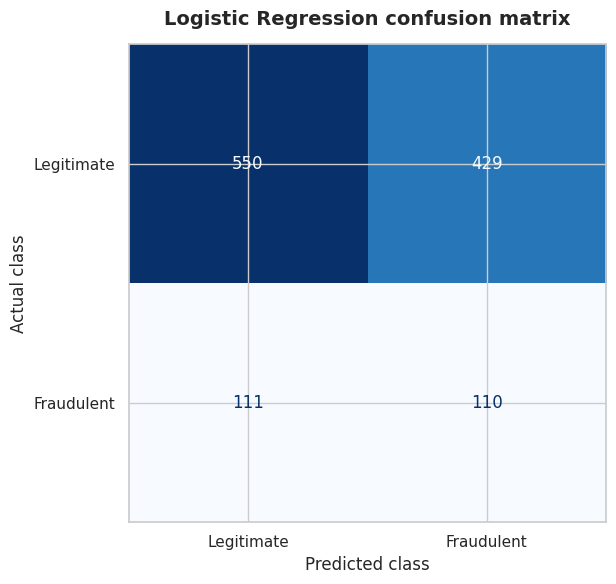

In [53]:
fig, axis = plt.subplots(figsize=(7, 6))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=[
        "Legitimate",
        "Fraudulent"
    ]
)

display_matrix.plot(
    cmap="Blues",
    values_format=",d",
    colorbar=False,
    ax=axis
)

axis.set_title(
    "Logistic Regression confusion matrix",
    fontsize=14,
    fontweight="bold",
    pad=14
)

axis.set_xlabel("Predicted class")
axis.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

In [54]:
logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_fpr_curve, logistic_tpr_curve, logistic_thresholds = (
    roc_curve(
        y_test,
        logistic_probabilities
    )
)

print(
    "Logistic Regression ROC-AUC:",
    f"{logistic_roc_auc:.4f}"
)

Logistic Regression ROC-AUC: 0.5584


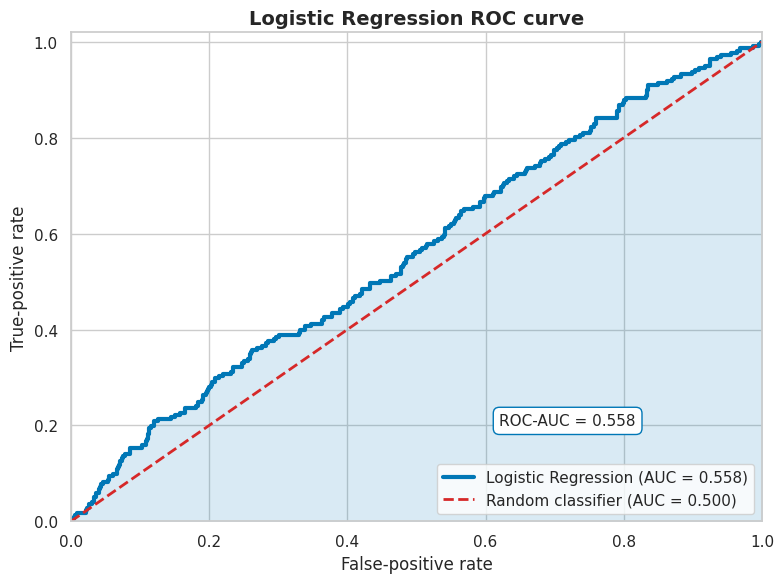

In [55]:
fig, axis = plt.subplots(figsize=(8, 6))

axis.plot(
    logistic_fpr_curve,
    logistic_tpr_curve,
    color="#0077B6",
    linewidth=3,
    label=(
        "Logistic Regression "
        f"(AUC = {logistic_roc_auc:.3f})"
    )
)

axis.plot(
    [0, 1],
    [0, 1],
    color="#D62828",
    linestyle="--",
    linewidth=2,
    label="Random classifier (AUC = 0.500)"
)

axis.fill_between(
    logistic_fpr_curve,
    logistic_tpr_curve,
    alpha=0.15,
    color="#0077B6"
)

axis.text(
    0.62,
    0.20,
    f"ROC-AUC = {logistic_roc_auc:.3f}",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "#0077B6",
        "boxstyle": "round,pad=0.4"
    }
)

axis.set_title(
    "Logistic Regression ROC curve",
    fontsize=14,
    fontweight="bold"
)

axis.set_xlabel("False-positive rate")
axis.set_ylabel("True-positive rate")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1.02)
axis.legend(loc="lower right")

plt.tight_layout()
plt.show()

## **Logistic Regression false-positive rate**

In [56]:
logistic_false_positive_rate = (
    logistic_fp / (logistic_fp + logistic_tn)
    if (logistic_fp + logistic_tn) > 0
    else np.nan
)

print(
    "Logistic Regression false-positive rate:",
    f"{logistic_false_positive_rate:.2%}"
)

Logistic Regression false-positive rate: 43.82%


# **XGBoost Classifier**

In [57]:
number_of_legitimate_training_claims = int(
    (y_train == 0).sum()
)

number_of_fraudulent_training_claims = int(
    (y_train == 1).sum()
)

scale_positive_weight = (
    number_of_legitimate_training_claims
    / number_of_fraudulent_training_claims
)

print(
    "Legitimate training claims:",
    number_of_legitimate_training_claims
)

print(
    "Fraudulent training claims:",
    number_of_fraudulent_training_claims
)

print(
    "XGBoost scale_pos_weight:",
    f"{scale_positive_weight:.4f}"
)

Legitimate training claims: 3916
Fraudulent training claims: 884
XGBoost scale_pos_weight: 4.4299


In [58]:
xgboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=3,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=0.10,
                reg_lambda=1.00,
                scale_pos_weight=scale_positive_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [59]:
xgboost_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('median_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['claim_amount',
                                                   'days_since_policy_start',
                                                   'num_prior_claims',
                                                   'incident_report_delay_days',
                                                   'is_weekend_claim',
                                                   'policy_tenure_years']),
                                                 ('categorical',
                                                  Pipeline(steps=[(...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [60]:
xgboost_predictions = (
    xgboost_pipeline.predict(X_test)
)

xgboost_probabilities = (
    xgboost_pipeline.predict_proba(X_test)[:, 1]
)

print("XGBoost predictions generated.")
print("Predicted legitimate claims:", (xgboost_predictions == 0).sum())
print("Predicted fraudulent claims:", (xgboost_predictions == 1).sum())

XGBoost predictions generated.
Predicted legitimate claims: 852
Predicted fraudulent claims: 348


In [61]:
xgboost_accuracy = accuracy_score(
    y_test,
    xgboost_predictions
)

print(
    "XGBoost accuracy:",
    f"{xgboost_accuracy:.4f}"
)

print(
    "XGBoost accuracy percentage:",
    f"{xgboost_accuracy * 100:.2f}%"
)

XGBoost accuracy: 0.6475
XGBoost accuracy percentage: 64.75%


In [62]:
print("XGBOOST CLASSIFICATION REPORT")
print("=" * 50)

xgboost_classification_report = classification_report(
    y_test,
    xgboost_predictions,
    target_names=[
        "Legitimate",
        "Fraudulent"
    ],
    zero_division=0
)

print(xgboost_classification_report)

xgboost_report_table = pd.DataFrame(
    classification_report(
        y_test,
        xgboost_predictions,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        output_dict=True,
        zero_division=0
    )
).transpose()

display(xgboost_report_table.round(4))

XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.83      0.72      0.77       979
  Fraudulent       0.21      0.33      0.26       221

    accuracy                           0.65      1200
   macro avg       0.52      0.52      0.51      1200
weighted avg       0.71      0.65      0.67      1200



,precision,recall,f1-score,support
Legitimate,0.8263,0.7191,0.7690,979.0000
Fraudulent,0.2098,0.3303,0.2566,221.0000
accuracy,0.6475,0.6475,0.6475,0.6475
macro avg,0.5180,0.5247,0.5128,1200.0000
weighted avg,0.7127,0.6475,0.6746,1200.0000


In [63]:
xgboost_log_loss = log_loss(
    y_test,
    xgboost_probabilities
)

print(
    "XGBoost log loss:",
    f"{xgboost_log_loss:.6f}"
)

XGBoost log loss: 0.645363


In [64]:
xgboost_confusion_matrix = confusion_matrix(
    y_test,
    xgboost_predictions,
    labels=[0, 1]
)

xgboost_tn, xgboost_fp, xgboost_fn, xgboost_tp = (
    xgboost_confusion_matrix.ravel()
)

print("XGBoost confusion matrix:")
print(xgboost_confusion_matrix)

print("\nTrue negatives:", xgboost_tn)
print("False positives:", xgboost_fp)
print("False negatives:", xgboost_fn)
print("True positives:", xgboost_tp)

XGBoost confusion matrix:
[[704 275]
 [148  73]]

True negatives: 704
False positives: 275
False negatives: 148
True positives: 73


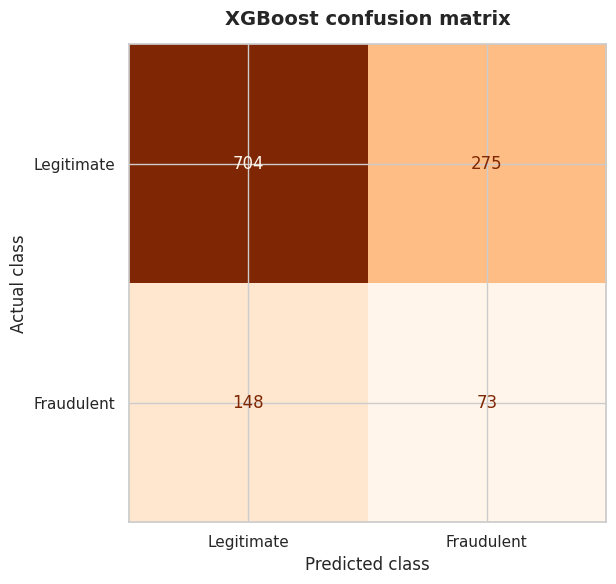

In [65]:
fig, axis = plt.subplots(figsize=(7, 6))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=xgboost_confusion_matrix,
    display_labels=[
        "Legitimate",
        "Fraudulent"
    ]
)

display_matrix.plot(
    cmap="Oranges",
    values_format=",d",
    colorbar=False,
    ax=axis
)

axis.set_title(
    "XGBoost confusion matrix",
    fontsize=14,
    fontweight="bold",
    pad=14
)

axis.set_xlabel("Predicted class")
axis.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

In [66]:
xgboost_roc_auc = roc_auc_score(
    y_test,
    xgboost_probabilities
)

xgboost_fpr_curve, xgboost_tpr_curve, xgboost_thresholds = (
    roc_curve(
        y_test,
        xgboost_probabilities
    )
)

print(
    "XGBoost ROC-AUC:",
    f"{xgboost_roc_auc:.4f}"
)

XGBoost ROC-AUC: 0.5141


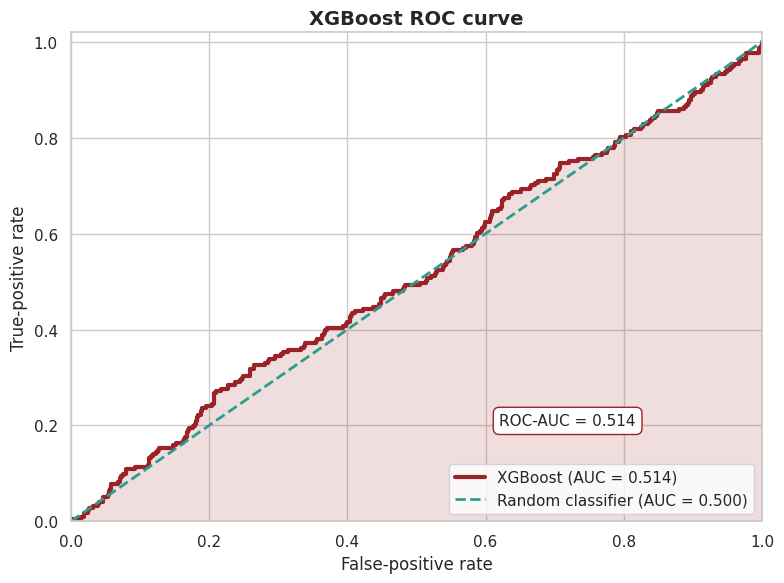

In [67]:
fig, axis = plt.subplots(figsize=(8, 6))

axis.plot(
    xgboost_fpr_curve,
    xgboost_tpr_curve,
    color="#9B2226",
    linewidth=3,
    label=(
        "XGBoost "
        f"(AUC = {xgboost_roc_auc:.3f})"
    )
)

axis.plot(
    [0, 1],
    [0, 1],
    color="#2A9D8F",
    linestyle="--",
    linewidth=2,
    label="Random classifier (AUC = 0.500)"
)

axis.fill_between(
    xgboost_fpr_curve,
    xgboost_tpr_curve,
    alpha=0.15,
    color="#9B2226"
)

axis.text(
    0.62,
    0.20,
    f"ROC-AUC = {xgboost_roc_auc:.3f}",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "#9B2226",
        "boxstyle": "round,pad=0.4"
    }
)

axis.set_title(
    "XGBoost ROC curve",
    fontsize=14,
    fontweight="bold"
)

axis.set_xlabel("False-positive rate")
axis.set_ylabel("True-positive rate")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1.02)
axis.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [68]:
xgboost_false_positive_rate = (
    xgboost_fp / (xgboost_fp + xgboost_tn)
    if (xgboost_fp + xgboost_tn) > 0
    else np.nan
)

print(
    "XGBoost false-positive rate:",
    f"{xgboost_false_positive_rate:.2%}"
)

XGBoost false-positive rate: 28.09%
